# Final Project: ANN to predict molecular energies using the ANI-1 dataset

## Importing Libraries and Loading Data

In [2]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


In [5]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

In [6]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

## Building a simple ANN

In [7]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.0537, grad_fn=<MseLossBackward0>)


In [17]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data if isinstance(train_data, list) else train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            train_total_samples = 0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = len(true_energies)
                train_epoch_loss += batch_loss.item() * batch_importance
                train_total_samples += batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss / train_total_samples)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(self.epoch), train_loss_list, label='Train')
            ax.plot(range(self.epoch), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data if isinstance(data, list) else data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        total_samples = 0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)

                batch_importance = len(true_energies)
                total_loss += batch_loss.item() * batch_importance
                total_samples += batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            return total_loss / total_samples, mae
            
        return total_loss / total_samples
        

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [17:10<00:00, 34.36s/it]


2.6991346601377674e-05

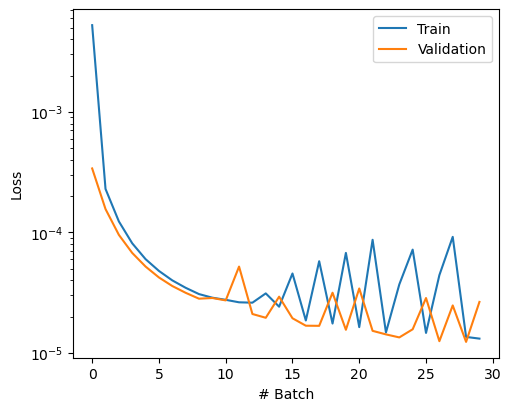

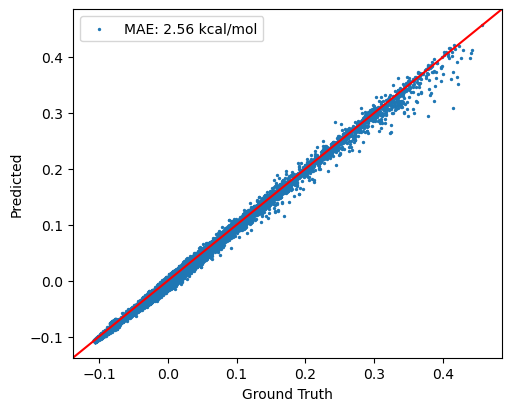

In [14]:
# no regularization
aev_computer = init_aev_computer()

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=30,
    l2=0
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

## Tuning the baseline model with regularization strategies and hyperparameter tuning

Above are the baseline matrics from checkpoint 2 that I will compare my tuning with.

### Playing around with regularization parameters for l2

### L2 Regularization with penalty term = 1e-6

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:56<00:00, 33.89s/it]


7.361820028749305e-05

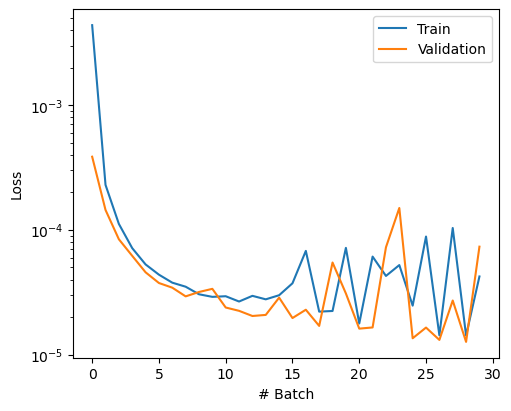

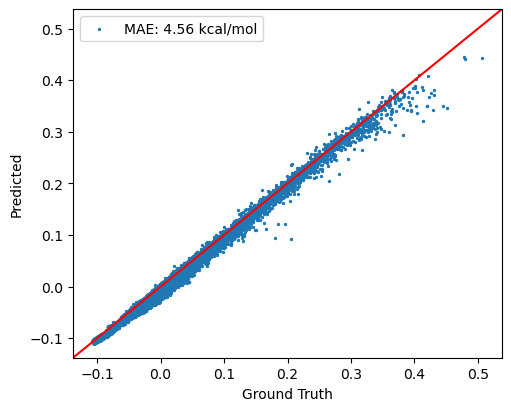

In [15]:
aev_computer = init_aev_computer()

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=30,
    l2=1e-6
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### L2 Regularization with penalty term = 1e-7

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [17:03<00:00, 34.13s/it]


1.4418738160374954e-05

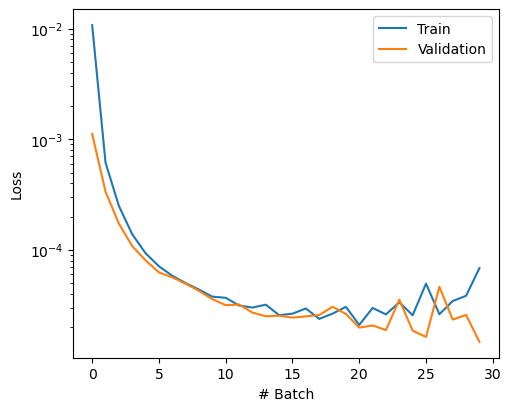

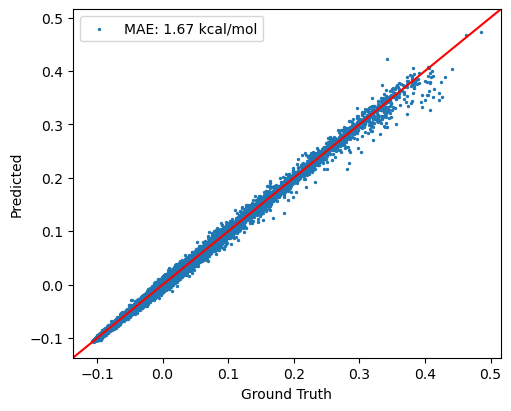

In [17]:
aev_computer = init_aev_computer()

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=30,
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### L2 Regularization with penalty term = 1e-8

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:52<00:00, 33.76s/it]


4.5143571336368174e-05

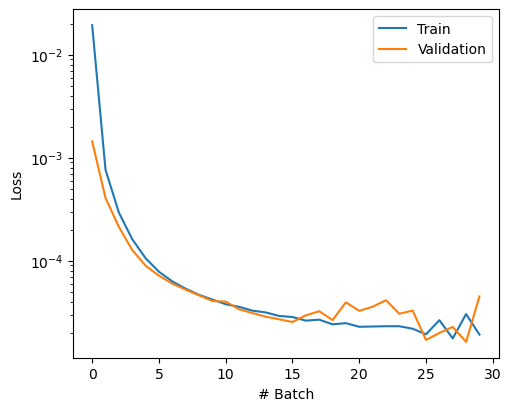

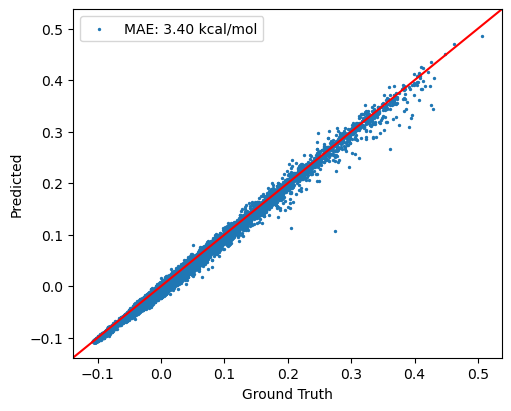

In [18]:
aev_computer = init_aev_computer()

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=30,
    l2=1e-8
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

From all the different L2 regularization parameters I could use, 1e-7 is clearly the winner because it shows a smooth loss curve with little indication of there being any underfitting or overfitting. No regularization and 1e-6 are both very spiky and 1e-8 underfits slightly because the overall loss value is higher than for the other values for the train set. So, I will use 1e-7!

### Adding dropout

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 50/50 [27:11<00:00, 32.63s/it]


2.9593520744437178e-05

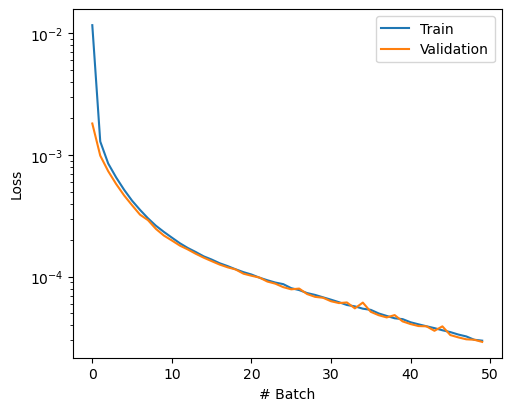

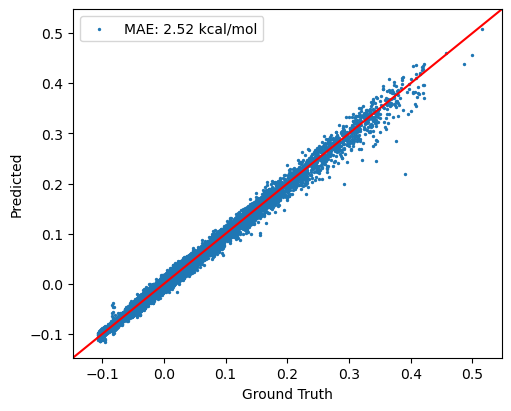

In [22]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, val_data, test_data = dataset.split(0.7, 0.2, 0.1)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=50,
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

Dropout isn't helping as much as I thought it would here. Despite it not converging yet, the MAE is 2.52 kcal/mol whereas my best MAE (which I got with regularization with penalty term 1e-7) was 1.67kcal/mol. Obviously this could be different with more epochs but one issue with dropout might be due to the small network with only one hidden layer so I will retry with more layers.

### Adding dropout + more layers for a deeper network

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 50/50 [37:38<00:00, 45.18s/it]


1.5619896127909725e-05

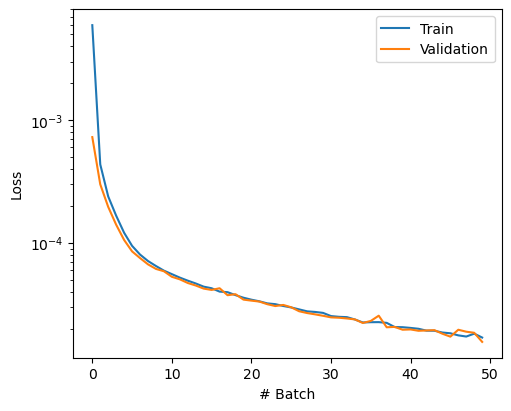

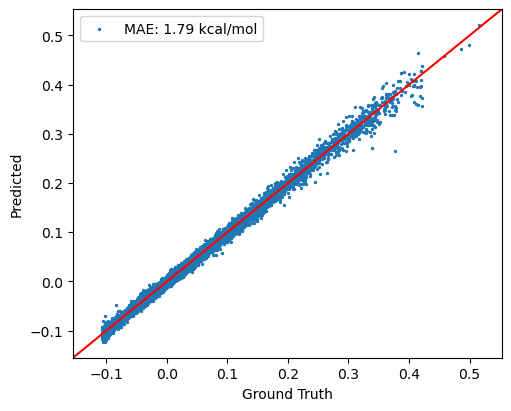

In [23]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=50,
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

Our new MAE is decent but still not as good as my best one (1.67). The curve is still not converging at 50 epochs so I should increase it more to help bring down the MAE further. I'm also going to add another hidden layer as this seems to be helping the dropout (MAE decreased with same number of epochs). I will first run the new architecture without dropout to more clearly compare.

### Using 3 hidden layers and dropout

Sequential - Number of parameters: 477244
Initialize training data...


100%|██████████| 70/70 [48:09<00:00, 41.28s/it]


1.1297714813277134e-05

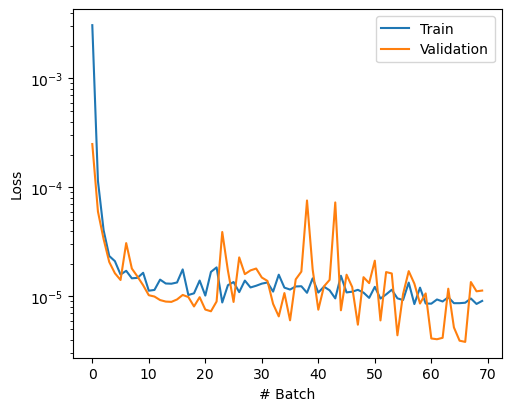

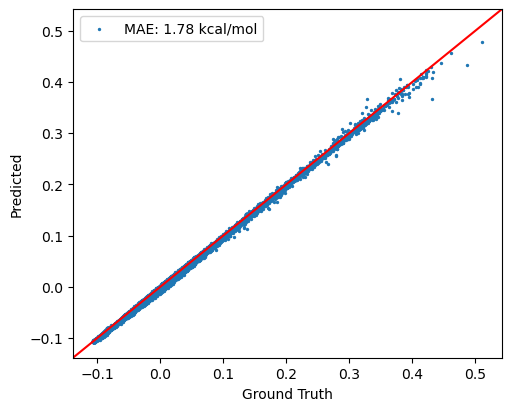

In [10]:
# without dropout
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 200),
            nn.ReLU(),
            nn.Linear(200, 150),
            nn.ReLU(),
            nn.Linear(150, 80),
            nn.ReLU(),
            nn.Linear(80, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=70, #increasing epochs to try get it to converge
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

Sequential - Number of parameters: 477244
Initialize training data...


100%|██████████| 70/70 [46:36<00:00, 39.95s/it]


1.4640156409703008e-05

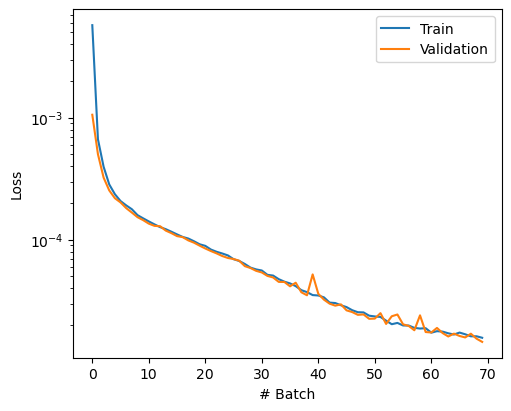

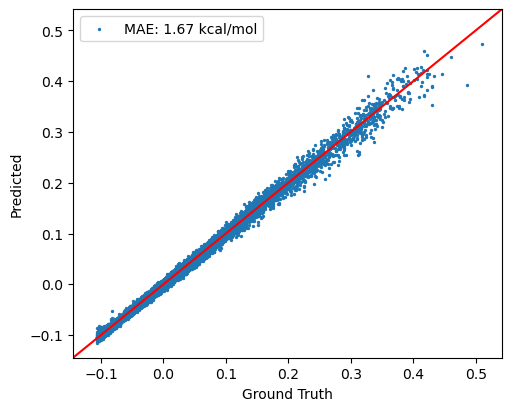

In [11]:
# with dropout
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 200),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(200, 150),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(150, 80),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(80, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=70, #increasing epochs to try get it to converge
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

Sequential - Number of parameters: 477244
Initialize training data...


100%|██████████| 90/90 [58:19<00:00, 38.89s/it]


1.7318788145319142e-05

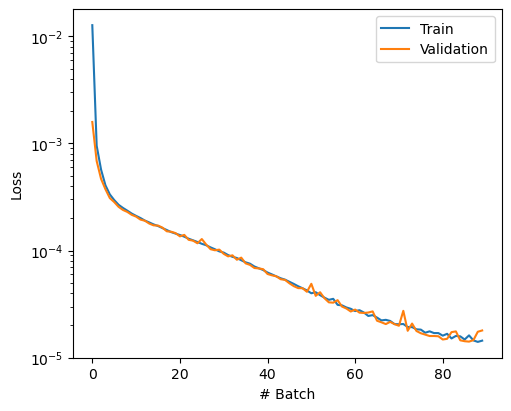

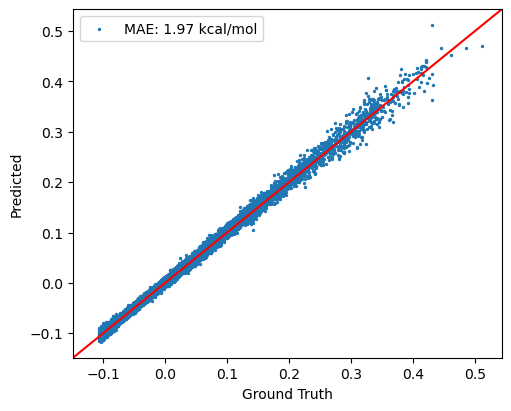

In [14]:
# with dropout
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 200),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(200, 150),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(150, 80),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(80, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

trainer = ANITrainer(
    model=model,
    batch_size=8192,
    learning_rate=1e-3,
    epoch=90, #increasing epochs to try get it to converge
    l2=1e-7
)

train_loss, val_loss = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

After these experiments with architecture and regularization, I've decided that sticking to my first simple model with regularization parameter 1e-7 and the one hidden layer might be best since my complex models aren't performing too much better and taking a long time to train. Despite getting 1.67kcal/mol MAE for the dropout and 3 hidden layers, when I increased the epochs the MAE went up to MAE 1.97. I got MAE 1.67kcal/mol with the simple architecture (L2 1e-7 (which is my best MAE) so I'm confident that this will suffice!

## Cross Validation

I edited two lines in my ANITrainer.train() so that it can also accept my list of batch sensors since before the ANITrainer only expected torchani dataset objects. I also edited it so that returns MAE

In [14]:
#turned into a custom function
def build_model():

    aev_computer = init_aev_computer()
    
    net_H = AtomicNet()
    net_C = AtomicNet()
    net_N = AtomicNet()
    net_O = AtomicNet()

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    return nn.Sequential(aev_computer, ani_net).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:33<00:00, 33.11s/it]


Fold 1: MAE = 1.660 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:08<00:00, 32.27s/it]


Fold 2: MAE = 1.749 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


...

Fold 3: MAE = 7.014 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:24<00:00, 32.82s/it]


Fold 4: MAE = 3.205 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:16<00:00, 32.56s/it]


Fold 5: MAE = 5.032 kcal/mol
K-fold CV (K=5): 3.732 ± 2.048 kcal/mol


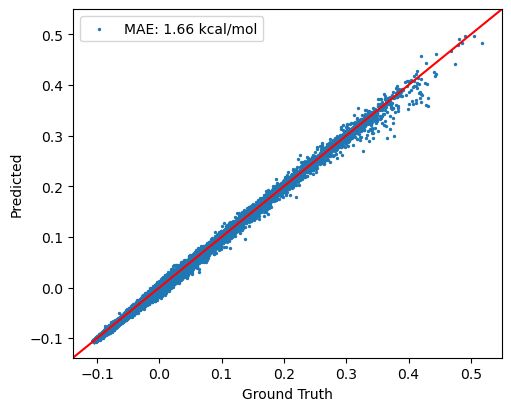

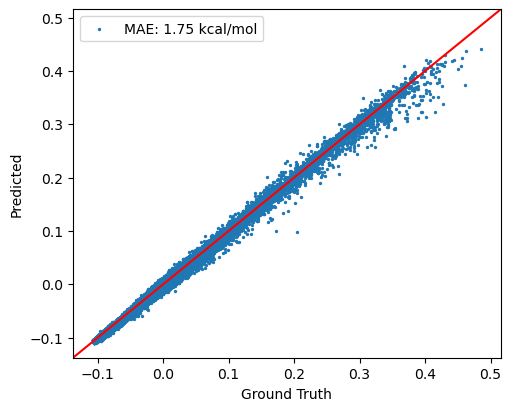

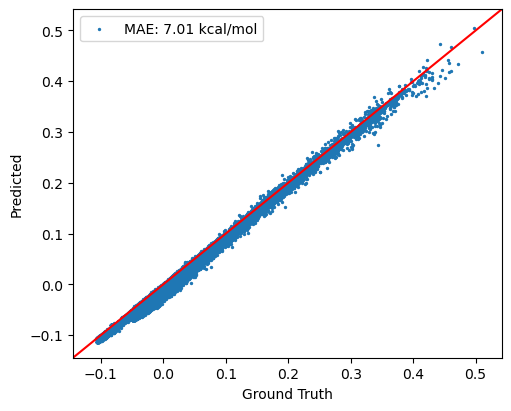

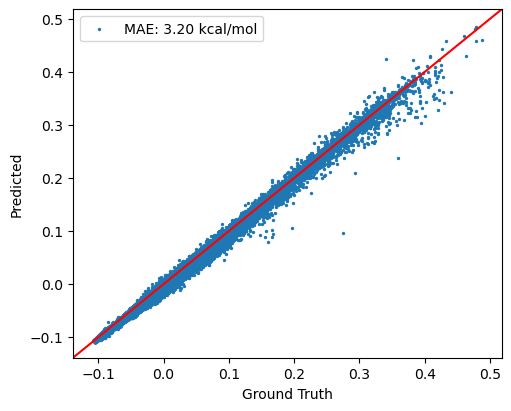

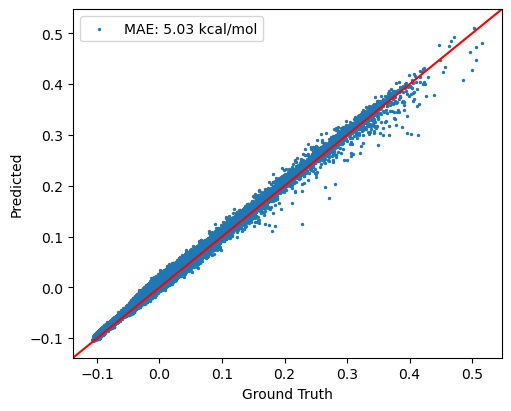

In [18]:
dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
all_batches = list(dataset.collate(8192).cache())
K, fold_size = 5, len(all_batches) // 5
mae_cv = []

for fold in range(K):
    val_fold   = all_batches[fold*fold_size : (fold+1)*fold_size]
    train_fold = all_batches[:fold*fold_size] + all_batches[(fold+1)*fold_size:]
    
    model = build_model()
    trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=30, l2=1e-7)
    trainer.train(train_fold, val_fold, early_stop=True, draw_curve=False)
    loss, mae = trainer.evaluate(val_fold, draw_plot=True)
    mae_cv.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.3f} kcal/mol")

print(f"K-fold CV (K={K}): {np.mean(mae_cv):.3f} ± {np.std(mae_cv):.3f} kcal/mol")

I think this variability is a result of me not shuffling the batches, I will re-run and shuffle this next time.

### Cross-Validation with shuffled data

In [20]:
import random

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:31<00:00, 33.06s/it]


Fold 1: MAE = 2.145 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [16:51<00:00, 33.71s/it]


Fold 2: MAE = 1.423 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


...

Fold 3: MAE = 1.752 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [15:43<00:00, 31.44s/it]


Fold 4: MAE = 1.391 kcal/mol
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 30/30 [15:57<00:00, 31.92s/it]


Fold 5: MAE = 1.589 kcal/mol
K-fold CV (K=5): 1.660 ± 0.275 kcal/mol


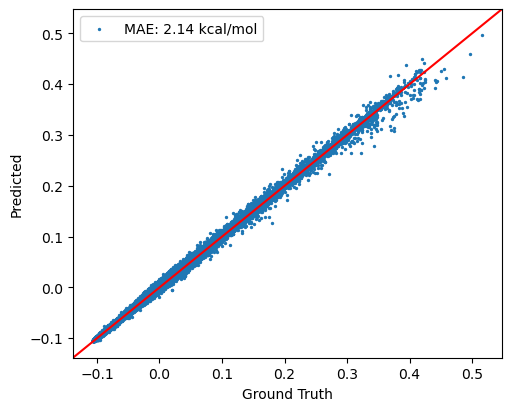

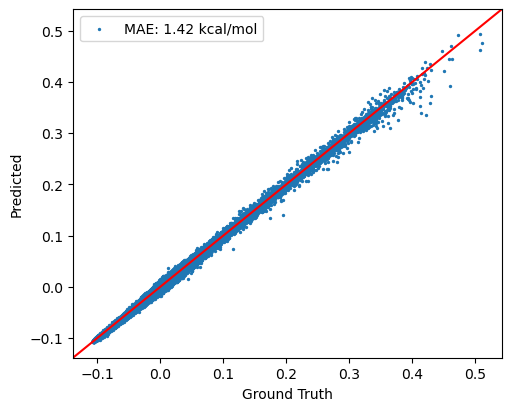

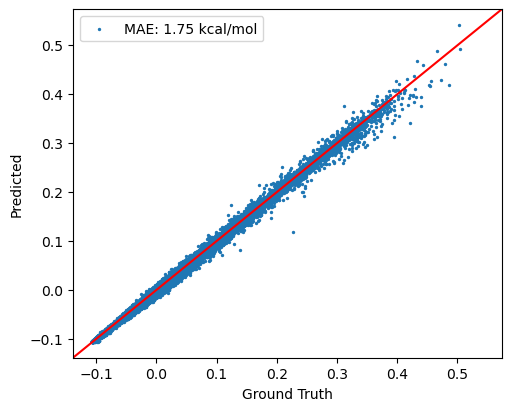

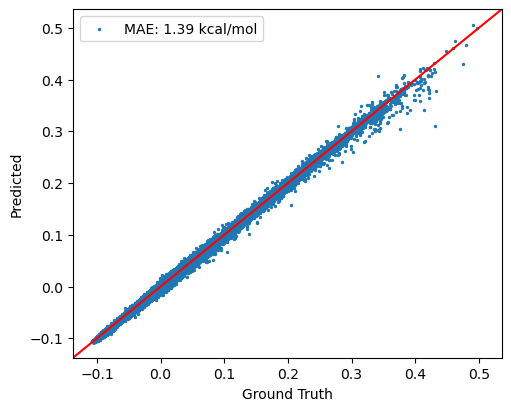

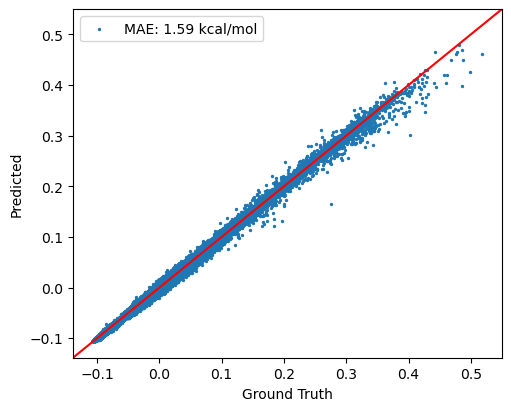

In [24]:
dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
all_batches = list(dataset.collate(8192).cache())
random.shuffle(all_batches)
K, fold_size = 5, len(all_batches) // 5
mae_cv = []

for fold in range(K):
    val_fold   = all_batches[fold*fold_size : (fold+1)*fold_size]
    train_fold = all_batches[:fold*fold_size] + all_batches[(fold+1)*fold_size:]
    
    model = build_model()
    trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=30, l2=1e-7)
    trainer.train(train_fold, val_fold, early_stop=True, draw_curve=False)
    loss, mae = trainer.evaluate(val_fold, draw_plot=True)
    mae_cv.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.3f} kcal/mol")

print(f"K-fold CV (K={K}): {np.mean(mae_cv):.3f} ± {np.std(mae_cv):.3f} kcal/mol")

I also played around with a way to use the old architecture ANITrainer (without my new modifications) and converted the dataset into a list of pre-batched tensors for slightly different training set ups. I did full runs with this new set up. I also reorganised some of the code into helper functions to support the input of pre-batched tensor lists. I also added some normalization for these full runs and changed early stopping. Another difference is the shuffling of all_batches which I did before but won't do now.

In [11]:
dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
all_batches = list(dataset.collate(8192).cache())

all_energies = torch.cat([batch['energies'].float() for batch in all_batches])
energy_mean = all_energies.mean().item()
energy_std  = all_energies.std().item()
for batch in all_batches:
    batch['energies'] = (batch['energies'].float() - energy_mean) / energy_std

In [12]:
hartree2kcalmol = 627.5094738898777

def build_model():

    aev_computer = init_aev_computer()
    
    net_H = AtomicNet()
    net_C = AtomicNet()
    net_N = AtomicNet()
    net_O = AtomicNet()

    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    return nn.Sequential(aev_computer, ani_net).to(device)

#using code from prev checkpoints
def compute_mae(model, batches):
    hartree2kcalmol = 627.5094738898777
    model.eval()
    true_all, pred_all = [], []
    with torch.no_grad():
        for b in batches:
            _, pred_e = model((b['species'].to(device), b['coordinates'].to(device)))
            true_all.append(b['energies'].to(device).float().cpu().numpy().flatten())
            pred_all.append(pred_e.cpu().numpy().flatten())
    return np.mean(np.abs(np.concatenate(true_all) - np.concatenate(pred_all))) * energy_std * hartree2kcalmol

def train_on_batches(model, train_b, val_b, lr=1e-3, l2=1e-7, epochs=30):
    optimizer, loss_func = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2), nn.MSELoss()
    best_val, best_weights = np.inf, None
    for _ in tqdm(range(epochs), leave=False):
        model.train()
        for b in train_b:
            _, pred_e = model((b['species'].to(device), b['coordinates'].to(device)))
            loss = loss_func(b['energies'].to(device).float(), pred_e)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for b in val_b:
                _, pred_e = model((b['species'].to(device), b['coordinates'].to(device)))
                val_loss += loss_func(b['energies'].to(device).float(), pred_e).item() * len(b['energies'])
                val_n += len(b['energies'])
        if (val_loss / val_n) < best_val:
            best_val, best_weights = val_loss / val_n, model.state_dict()
    model.load_state_dict(best_weights)

In [13]:
n = len(all_batches)
train_b, val_b, test_b = all_batches[:int(0.7*n)], all_batches[int(0.7*n):int(0.9*n)], all_batches[int(0.9*n):]

mae_runs = []
for run in range(5):
    torch.manual_seed(run)
    model = build_model()
    train_on_batches(model, train_b, val_b)
    mae_runs.append(compute_mae(model, test_b))
    print(f"Run {run+1}: MAE = {mae_runs[-1]:.3f} kcal/mol")
print(f"\nMultiple runs: {np.mean(mae_runs):.3f} ± {np.std(mae_runs):.3f} kcal/mol")

K, fold_size = 5, n // 5
mae_cv = []
for fold in range(K):
    val_fold   = all_batches[fold*fold_size : (fold+1)*fold_size]
    train_fold = all_batches[:fold*fold_size] + all_batches[(fold+1)*fold_size:]
    torch.manual_seed(42)
    model = build_model()
    train_on_batches(model, train_fold, val_fold)
    mae_cv.append(compute_mae(model, val_fold))
    print(f"Fold {fold+1}: MAE = {mae_cv[-1]:.3f} kcal/mol")
print(f"\nK-fold CV (K={K}): {np.mean(mae_cv):.3f} ± {np.std(mae_cv):.3f} kcal/mol")

Run 1: MAE = 1.787 kcal/mol


Run 2: MAE = 1.142 kcal/mol


Run 3: MAE = 1.141 kcal/mol


Run 4: MAE = 1.072 kcal/mol


Run 5: MAE = 1.450 kcal/mol

Multiple runs: 1.318 ± 0.269 kcal/mol


Fold 1: MAE = 1.042 kcal/mol


Fold 2: MAE = 1.159 kcal/mol


Fold 3: MAE = 1.421 kcal/mol


Fold 4: MAE = 1.014 kcal/mol


Fold 5: MAE = 1.943 kcal/mol

K-fold CV (K=5): 1.316 ± 0.345 kcal/mol


## Conclusion

Overall, very similar results to when I shuffled all_batches above. Also, these results are all below 2 MAE and perform consistently well around 1.3 kcal/mol with little variation.

In my notebook, I run 5-fold cross-validation and multiple runs of my full model on the data, whereas the paper doesn't have this same reproducibility. The test errors are similar: my average test error is 1.3-1.45 whereas the test error reported in the paper is 1.3 RMSE. I do acknolwedge however that RMSE and MAE do penalize outliers differently, since the squaring of the residuals in the RMSE penalizes larger errors more, however the metrics are similar enough and on the same scale that I would say they're still comparable. The architecture were also slightly different, the one in the paper used a slightly more complex architecture however since the accuracies are similar, one could argue that the extra depth in the network has little effect.